In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
from sklearn.datasets import make_moons
x, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [174]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
print("first 10 rows:")
df.head(10)


first 10 rows:


,feature1,feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
5,1.254903,-0.483435
6,1.053851,-0.442690
7,0.031380,1.053012
8,0.620545,0.713096
9,1.787657,-0.142959


In [175]:
df.shape

(500, 2)

In [176]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
print("First 5 rows of scaled data:")
print(x_scaled[:5])


First 5 rows of scaled data:
[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


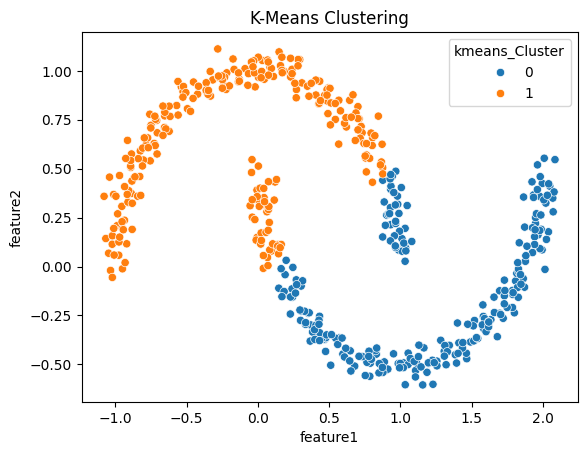

In [177]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
lables = kmeans.fit_predict(x_scaled)
df["kmeans_Cluster"] = lables

#Create a scatter plot to visualize the KMeans clusters
sns.scatterplot(x="feature1", y="feature2", hue="kmeans_Cluster", data=df)
plt.title("K-Means Clustering")
plt.show()


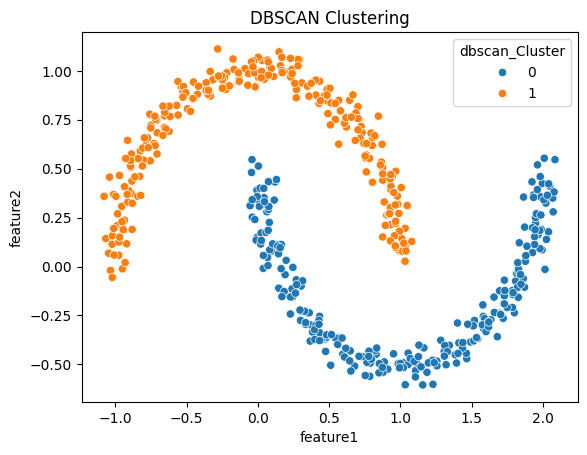

In [178]:
from sklearn.cluster import DBSCAN
model_dbscan = DBSCAN(eps=0.3, min_samples=5)
lables = model_dbscan.fit_predict(x_scaled)
df["dbscan_Cluster"] = lables

#Create a scatter plot to visualize the DBSCAN clusters
sns.scatterplot(x="feature1", y="feature2", hue="dbscan_Cluster", data=df)
plt.title("DBSCAN Clustering")
plt.show()

In [179]:
# Kmeans makes groups by checking the distance between the datapoints.
# Kmeans cannot makes the moon shape properly becoz it works better for rounded shaped clusters.
# DBSCAN makes the clusters based on the closely packed datapoints.
# DBSCAN makes the two moon shaped clusters properly & also find the noise points.
# so DBSCAN is works better than KMeans for the moon dataset.


In [180]:
from sklearn.cluster import DBSCAN
import pandas as pd

result = []

for eps in [0.2, 0.3, 0.4, 0.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(x_scaled)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    result.append([eps, clusters, noise])
result_df = pd.DataFrame(result,columns=["eps","Number of Clusters","Noise Points"])

print(result_df)

   eps  Number of Clusters  Noise Points
0  0.2                   2             0
1  0.3                   2             0
2  0.4                   2             0
3  0.5                   2             0


In [181]:
from sklearn.datasets import make_blobs

x,y = make_blobs(n_samples=500, n_features=6, centers=4, cluster_std=1.5, random_state=42)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [182]:
from sklearn.decomposition import PCA

model_pca = PCA(n_components=2)
x_pca = model_pca.fit_transform(x_scaled)
pca_df=pd.DataFrame(data=x_pca, columns=["PC1", "PC2"])
pca_df["Cluster"]=y
print("Variance Ratio:")
print(model_pca.explained_variance_ratio_)

Variance Ratio:
[0.64327878 0.21039738]


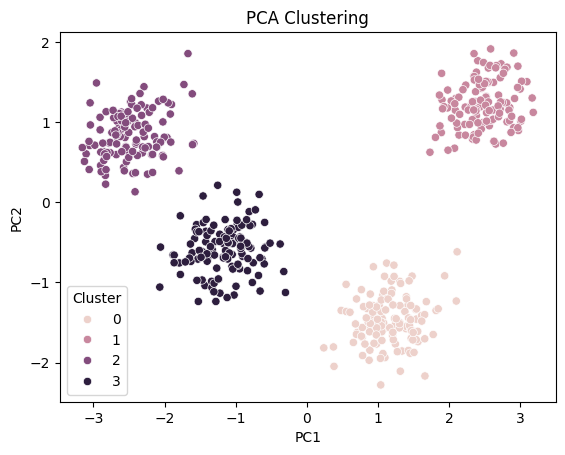

In [183]:
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df)
plt.title("PCA Clustering")
plt.show()

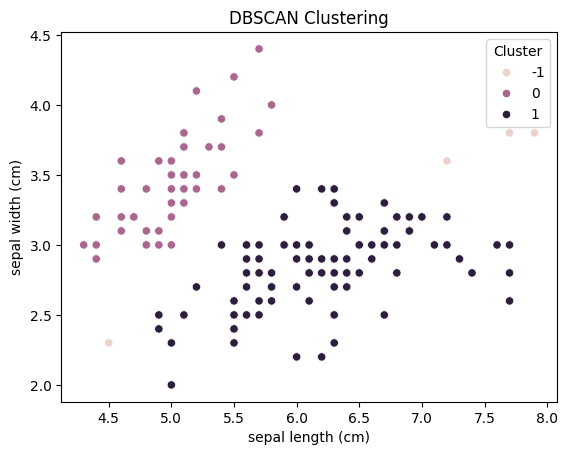

Variance Ratio:
[0.72962445 0.22850762]


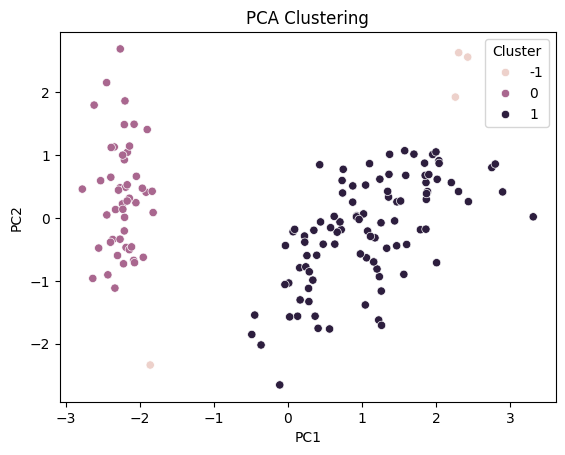

In [188]:
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

#numerical feartures
X=df

# Scale the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(x_scaled)
df["Cluster"]=labels

#Visulization of DBSCAN
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="Cluster", data=df)
plt.title("DBSCAN Clustering")
plt.show()

#Apply PCA
model_pca = PCA(n_components=2)
x_pca = model_pca.fit_transform(x_scaled)
pca_df=pd.DataFrame(data=x_pca, columns=["PC1", "PC2"])
pca_df["Cluster"]=labels
print("Variance Ratio:")
print(model_pca.explained_variance_ratio_)

#Visulization of PCA
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df)
plt.title("PCA Clustering")
plt.show()